In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [63]:
ss=1

yous=-2
shangjiao=-1+ss
duijiao=2
xiajiao=-1-ss
zuox=-0.5*0
N_shumu=6

def H(duijiao,xiajiao,shangjiao,zuox,yous,N_shumu):
    H=np.zeros((N_shumu, N_shumu), dtype=complex)
    for i in range(N_shumu):
        H[i][i]=duijiao
        if i == 0:
            H[i][N_shumu-1]=yous
        if i > 0:
            H[i][i-1] = xiajiao
        if i < N_shumu-1:
            H[i][i+1] = shangjiao
        if i == N_shumu-1:
            H[i][0]=zuox
    return H
H=H(duijiao,xiajiao,shangjiao,zuox,yous,N_shumu)
evals, evecs = np.linalg.eig(H)

probs=np.abs(evecs)**2/np.sum(evecs)

print(H)
print(evals)


[[ 2.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -2.+0.j]
 [-2.+0.j  2.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -2.+0.j  2.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j -2.+0.j  2.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -2.+0.j  2.+0.j  0.+0.j]
 [-0.+0.j  0.+0.j  0.+0.j  0.+0.j -2.+0.j  2.+0.j]]
[-3.24688963e-16-3.40348197e-16j  1.00000000e+00+1.73205081e+00j
  1.00000000e+00-1.73205081e+00j  3.00000000e+00+1.73205081e+00j
  3.00000000e+00-1.73205081e+00j  4.00000000e+00+0.00000000e+00j]


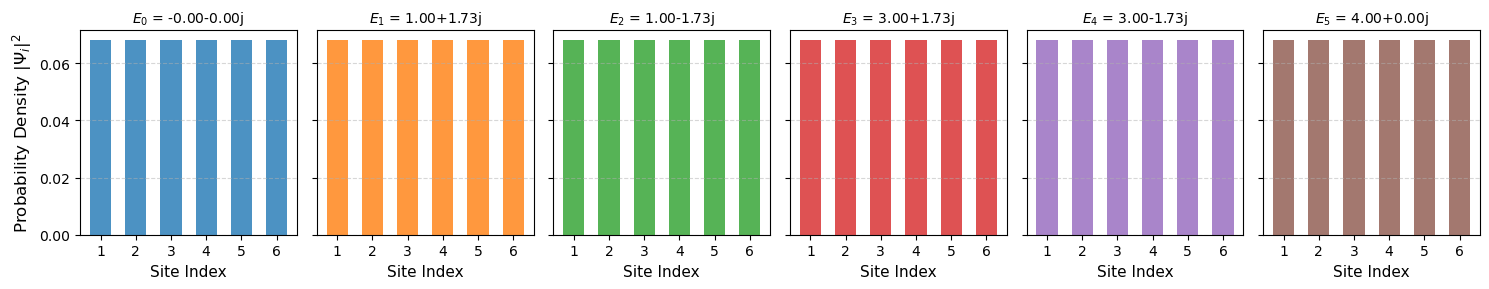

In [64]:
fig, axes = plt.subplots(1, N_shumu, figsize=(15, 3), sharey=True)

x = np.arange(1, N_shumu + 1)

for i in range(N_shumu):
    ax = axes[i]

    ax.bar(x, probs[:, i], width=0.6, color=f'C{i}', alpha=0.8)
    
    ax.set_title(f'$E_{i}$ = {evals[i].real:.2f}{evals[i].imag:+.2f}j', fontsize=10)
    ax.set_xlabel('Site Index', fontsize=11)
    ax.set_xticks(x)  
    
    if i == 0:
        ax.set_ylabel(r'Probability Density $|\Psi_i|^2$', fontsize=12)
        
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

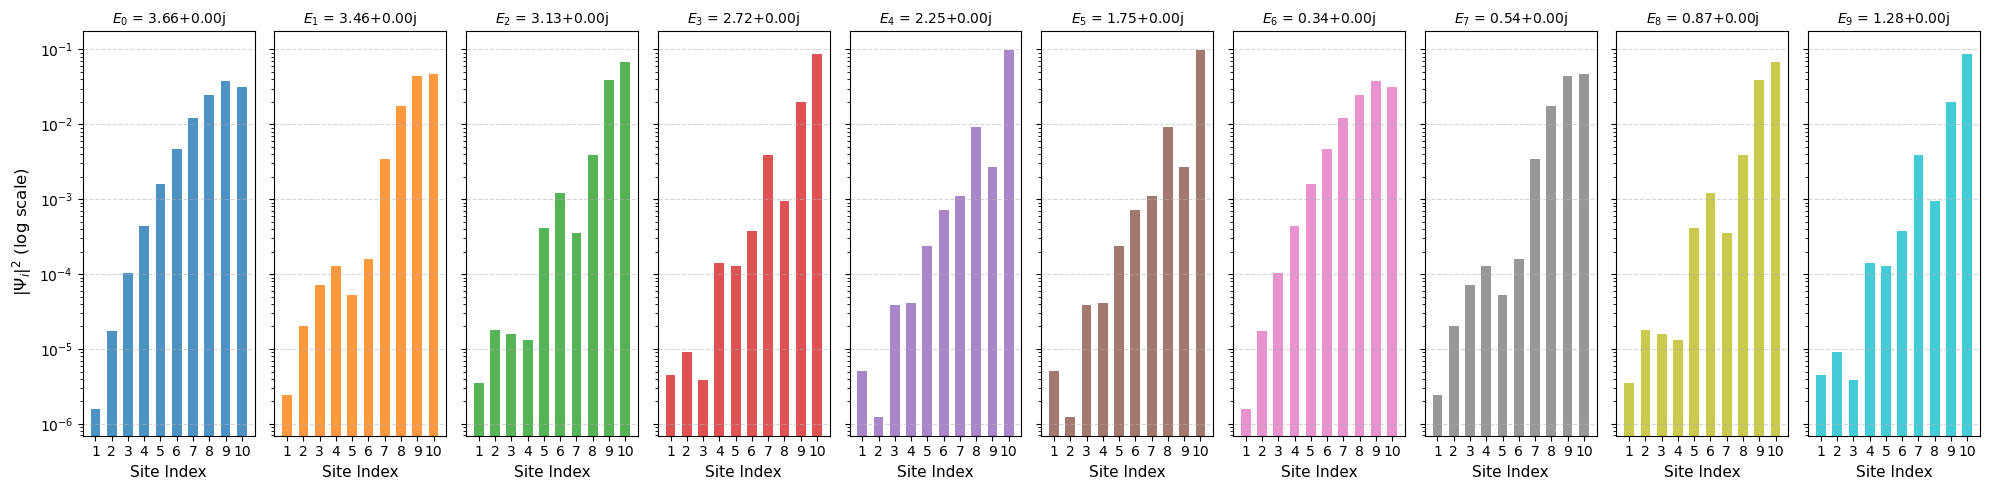

In [34]:
fig, axes = plt.subplots(1, N_shumu, figsize=(20, 5), sharey=True)

# ================= 核心修改 =================
# 添加画布总的大标题 (suptitle)
# 可以自己修改里面的文字，y=1.1 是为了给大标题留出空间，防止和子图标题重叠
#fig.suptitle(rf'G_15={G_15}', fontsize=16, fontweight='bold', y=1.1)
# ============================================

x = np.arange(1, N_shumu + 1)

for i in range(N_shumu):
    ax = axes[i]

    # 画柱状图
    ax.bar(x, probs[:, i], width=0.6, color=f'C{i}', alpha=0.8)
    
    # 将 y 轴设置为以 10 为底的对数坐标系 (log_10)
    ax.set_yscale('log')
    
    ax.set_title(f'$E_{i}$ = {evals[i].real:.2f}{evals[i].imag:+.2f}j', fontsize=10)
    ax.set_xlabel('Site Index', fontsize=11)
    ax.set_xticks(x)  
    
    if i == 0:
        # 顺便在 y 轴标签上标注一下是对数坐标
        ax.set_ylabel(r' $|\Psi_i|^2$ (log scale)', fontsize=12)
        
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

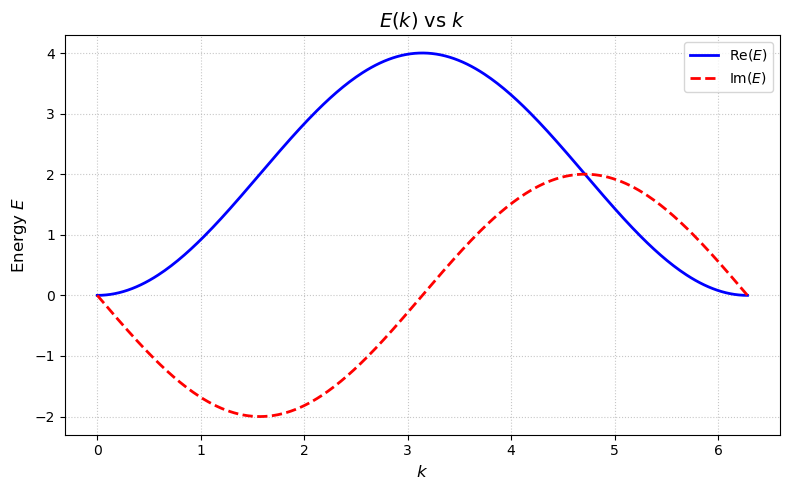

In [65]:
k_vals = np.linspace(0, 2 * np.pi, 300)
E_k = H[0][0] + H[1][0] * np.exp(1j * k_vals) + H[0][1] * np.exp(-1j * k_vals)
# ================= 3. 画出 E vs k 的能带图 =================
plt.figure(figsize=(8, 5))

# 横轴为 k_vals，纵轴分别为 E_k 的实部和虚部
plt.plot(k_vals, np.real(E_k), color='blue', linewidth=2, label=r'$\operatorname{Re}(E)$')
plt.plot(k_vals, np.imag(E_k), color='red', linewidth=2, linestyle='--', label=r'$\operatorname{Im}(E)$')

# 设置图表信息
plt.title(f'$E(k)$ vs $k$ ', fontsize=14)
plt.xlabel(r'$k$', fontsize=12)
plt.ylabel('Energy $E$', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()